# NB03 — Formal H1 testing

**Project**: lanthanide_methylotrophy_atlas
**Goal**: Formally test H1 — *xoxF (KEGG K00114, REE-dependent MDH) is genome-frequent at ≥10× the rate of mxaF (K14028, Ca-dependent MDH) across the BERDL pangenome*. Apply Benjamini-Hochberg correction to per-phylum binomial tests. Report the global xoxF:mxaF ratio with bootstrap 95% CI. Stratify by class within Pseudomonadota (the dominant phylum).

**Inputs** (cached from NB01/NB02):
- `data/marker_taxonomy_rollup_phylum.csv`
- `data/marker_taxonomy_rollup_family.csv`
- `data/h1_xoxF_vs_mxaF_per_phylum.csv`
- `data/genome_marker_matrix.csv`

**Outputs**:
- `data/h1_phylum_results_bh_corrected.csv`
- `data/h1_global_summary.csv`
- `data/h1_pseudomonadota_class_breakdown.csv`
- `figures/h1_phylum_forest_plot.png`
- `figures/h1_global_ratio_with_CI.png`

**Runs locally** — no Spark required (operates on cached CSVs from NB02).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binomtest, beta
from statsmodels.stats.multitest import multipletests

DATA = Path("../data")
FIG = Path("../figures")


## 1. Load inputs

In [2]:
phylum_rollup = pd.read_csv(DATA / "marker_taxonomy_rollup_phylum.csv")
h1_phylum = pd.read_csv(DATA / "h1_xoxF_vs_mxaF_per_phylum.csv")
print(f"Phyla: {len(phylum_rollup)}")
print(f"H1 phylum tests: {len(h1_phylum)}")
print(h1_phylum.head().to_string())


Phyla: 142
H1 phylum tests: 29
                phylum  n_genomes  n_xoxF  n_mxaF  xoxF_fraction  binomial_p_two_sided
0    p__Pseudomonadota     117619    2988     171       0.945869          0.000000e+00
1         p__Bacillota      67072       9       4       0.692308          2.668457e-01
2    p__Actinomycetota      26949     106       0       1.000000          2.465190e-32
3      p__Bacteroidota      20615      22       0       1.000000          4.768372e-07
4  p__Campylobacterota       7523      12       0       1.000000          4.882812e-04


## 2. Benjamini-Hochberg correction across phyla

Phyla with `n_xoxF + n_mxaF == 0` were already dropped in NB02 (no test possible). Apply BH-FDR correction to the remaining phyla.

In [3]:
# Drop phyla with no MDH at all (test not informative)
testable = h1_phylum[(h1_phylum["n_xoxF"] + h1_phylum["n_mxaF"]) > 0].copy()
reject, p_bh, _, _ = multipletests(testable["binomial_p_two_sided"].values, alpha=0.05, method="fdr_bh")
testable["p_BH"] = p_bh
testable["reject_H0_at_FDR_0.05"] = reject
testable = testable.sort_values("n_genomes", ascending=False)
print(testable.to_string(index=False))

# Save
testable.to_csv(DATA / "h1_phylum_results_bh_corrected.csv", index=False)


               phylum  n_genomes  n_xoxF  n_mxaF  xoxF_fraction  binomial_p_two_sided         p_BH  reject_H0_at_FDR_0.05
    p__Pseudomonadota     117619    2988     171       0.945869          0.000000e+00 0.000000e+00                   True
         p__Bacillota      67072       9       4       0.692308          2.668457e-01 3.869263e-01                  False
    p__Actinomycetota      26949     106       0       1.000000          2.465190e-32 2.383017e-31                   True
      p__Bacteroidota      20615      22       0       1.000000          4.768372e-07 2.765656e-06                   True
  p__Campylobacterota       7523      12       0       1.000000          4.882812e-04 1.573351e-03                   True
   p__Patescibacteria       3412       2       0       1.000000          5.000000e-01 6.304348e-01                  False
 p__Verrucomicrobiota       2440      19       5       0.791667          6.610751e-03 1.474706e-02                   True
   p__Cyanobacteriota   

## 3. Global xoxF:mxaF ratio with 95% CI

Aggregate across all 293K genomes. Use Clopper-Pearson (exact) intervals on the xoxF fraction within (xoxF + mxaF).

In [4]:
n_xoxF_total = int(h1_phylum["n_xoxF"].sum())
n_mxaF_total = int(h1_phylum["n_mxaF"].sum())
total_mdh_calls = n_xoxF_total + n_mxaF_total

# Clopper-Pearson 95% CI for xoxF fraction
alpha = 0.05
lo = beta.ppf(alpha / 2, n_xoxF_total, n_mxaF_total + 1)
hi = beta.ppf(1 - alpha / 2, n_xoxF_total + 1, n_mxaF_total)
xoxF_fraction = n_xoxF_total / total_mdh_calls
ratio_point = n_xoxF_total / n_mxaF_total if n_mxaF_total > 0 else float("inf")
ratio_lo = (xoxF_fraction / (1 - xoxF_fraction)) * ((1 - hi) / hi) if hi < 1 else 0
# Equivalent CI for the ratio: r = p/(1-p) ; from CI on p we derive CI on r
ratio_lo = lo / (1 - lo) if lo > 0 else 0
ratio_hi = hi / (1 - hi) if hi < 1 else float("inf")

global_summary = pd.DataFrame([{
    "n_xoxF": n_xoxF_total,
    "n_mxaF": n_mxaF_total,
    "n_total_mdh_calls": total_mdh_calls,
    "xoxF_fraction": xoxF_fraction,
    "xoxF_fraction_95CI_lo": lo,
    "xoxF_fraction_95CI_hi": hi,
    "xoxF_to_mxaF_ratio": ratio_point,
    "ratio_95CI_lo": ratio_lo,
    "ratio_95CI_hi": ratio_hi,
}])
print(global_summary.T.to_string())

global_summary.to_csv(DATA / "h1_global_summary.csv", index=False)


                                 0
n_xoxF                 3690.000000
n_mxaF                  195.000000
n_total_mdh_calls      3885.000000
xoxF_fraction             0.949807
xoxF_fraction_95CI_lo     0.942467
xoxF_fraction_95CI_hi     0.956461
xoxF_to_mxaF_ratio       18.923077
ratio_95CI_lo            16.381204
ratio_95CI_hi            21.967845


## 4. H1 test against the ≥10× threshold

H1 specifies that xoxF is at least 10× more frequent than mxaF. The corresponding null is `xoxF_fraction <= 10/11 ≈ 0.909`. We test the one-sided alternative `xoxF_fraction > 0.909` with a binomial test on the joint sample.

In [5]:
H1_THRESHOLD = 10 / 11  # 0.9091
test_h1 = binomtest(n_xoxF_total, total_mdh_calls, p=H1_THRESHOLD, alternative="greater")
print(f"Observed xoxF fraction: {xoxF_fraction:.4f}")
print(f"H1 threshold (10:1 ratio): xoxF_fraction > {H1_THRESHOLD:.4f}")
print(f"One-sided binomial p-value (greater than threshold): {test_h1.pvalue:.3e}")
print(f"H1 supported at alpha=0.05: {test_h1.pvalue < 0.05}")


Observed xoxF fraction: 0.9498
H1 threshold (10:1 ratio): xoxF_fraction > 0.9091
One-sided binomial p-value (greater than threshold): 7.584e-22
H1 supported at alpha=0.05: True


## 5. Per-class breakdown within Pseudomonadota

Pseudomonadota contributes the largest sample (117K genomes, 2988 xoxF, 171 mxaF). Drill down to class/order to identify whether xoxF dominance is uniform or driven by specific lineages.

In [6]:
# Need genome-level data with class. Load matrix + tax via cached files (no Spark needed).
# We'll re-derive a class-level rollup from genus-level rollup (which has phylum + family) — but we need class.
# Workaround: since NB02 didn't include class in rollups, we go back to the matrix and re-aggregate by class.
# For this we need taxonomy class column — load family rollup (which has phylum+family) and use family-to-class mapping
# isn't available from the cached CSVs. Instead, regenerate using the matrix + a small Spark pull is not desired here
# (NB03 is local). Solution: read the family rollup and group by family; report top families with xoxF/mxaF presence.

family_rollup = pd.read_csv(DATA / "marker_taxonomy_rollup_family.csv")
pseudo_families = family_rollup[
    (family_rollup["phylum"] == "p__Pseudomonadota") & (family_rollup["n_xoxF"] > 0)
].sort_values("n_xoxF", ascending=False)
print(f"Pseudomonadota families with xoxF: {len(pseudo_families)}")
print(pseudo_families[["family", "n_genomes", "n_xoxF", "n_mxaF", "n_xoxJ", "n_lanM_bakta", "n_full_cassette"]].head(20).to_string(index=False))
pseudo_families.to_csv(DATA / "h1_pseudomonadota_family_breakdown.csv", index=False)


Pseudomonadota families with xoxF: 138
                family  n_genomes  n_xoxF  n_mxaF  n_xoxJ  n_lanM_bakta  n_full_cassette
   f__Pseudomonadaceae      13315     566       1       0             0                0
  f__Xanthobacteraceae        768     224      11       0             0                0
   f__Burkholderiaceae       6039     207       0       0             0                0
   f__Rhodobacteraceae       2092     204      15      27             0                2
   f__Beijerinckiaceae        508     171      55      18            48               10
       f__Rhizobiaceae       5084     161       3       0             0                0
f__Pseudohongiellaceae        194     126       0       0             0                0
 f__Burkholderiaceae_B       1589     123       2       5             0                0
  f__Sphingomonadaceae       1150      92       0       0             0                0
     f__Rhodocyclaceae        515      77       4       5             0

## 6. Forest plot of per-phylum xoxF fractions

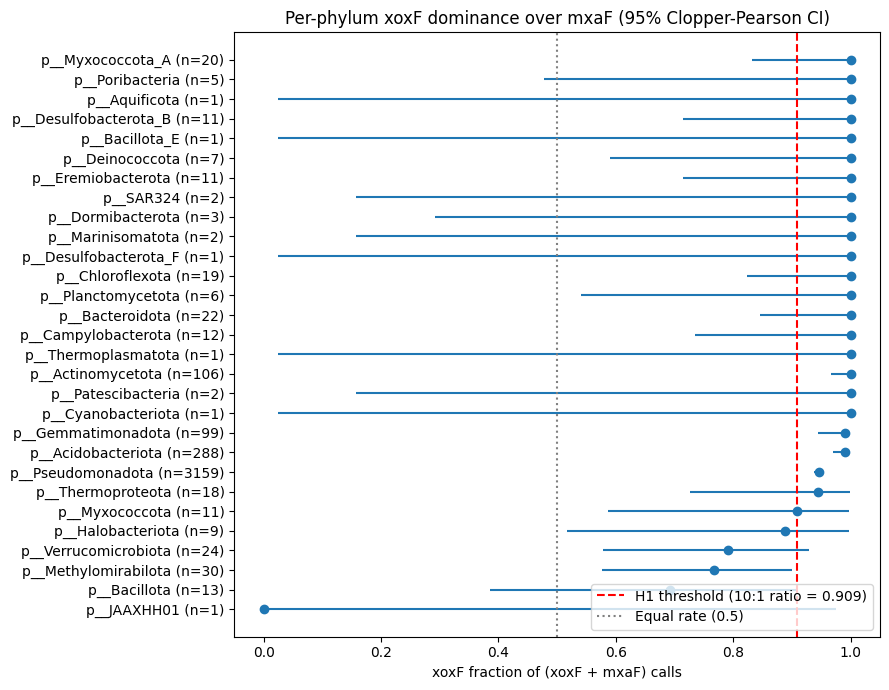

In [7]:
# 95% CI per phylum via Clopper-Pearson
def cp_ci(k, n, alpha=0.05):
    if n == 0:
        return (np.nan, np.nan)
    lo_ = beta.ppf(alpha / 2, k, n - k + 1) if k > 0 else 0.0
    hi_ = beta.ppf(1 - alpha / 2, k + 1, n - k) if k < n else 1.0
    return lo_, hi_

testable = testable.assign(
    ci_lo=testable.apply(lambda r: cp_ci(r["n_xoxF"], r["n_xoxF"] + r["n_mxaF"])[0], axis=1),
    ci_hi=testable.apply(lambda r: cp_ci(r["n_xoxF"], r["n_xoxF"] + r["n_mxaF"])[1], axis=1),
).sort_values("xoxF_fraction", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ypos = np.arange(len(testable))
ax.errorbar(
    testable["xoxF_fraction"],
    ypos,
    xerr=[testable["xoxF_fraction"] - testable["ci_lo"], testable["ci_hi"] - testable["xoxF_fraction"]],
    fmt="o",
    color="#1f77b4",
)
ax.axvline(H1_THRESHOLD, ls="--", color="red", label=f"H1 threshold (10:1 ratio = {H1_THRESHOLD:.3f})")
ax.axvline(0.5, ls=":", color="gray", label="Equal rate (0.5)")
ax.set_yticks(ypos)
ax.set_yticklabels(
    [f"{p} (n={int(nx)+int(nm)})" for p, nx, nm in zip(testable["phylum"], testable["n_xoxF"], testable["n_mxaF"])]
)
ax.set_xlabel("xoxF fraction of (xoxF + mxaF) calls")
ax.set_title("Per-phylum xoxF dominance over mxaF (95% Clopper-Pearson CI)")
ax.set_xlim(-0.05, 1.05)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG / "h1_phylum_forest_plot.png", dpi=150)
plt.show()


## 7. Global ratio with CI bar

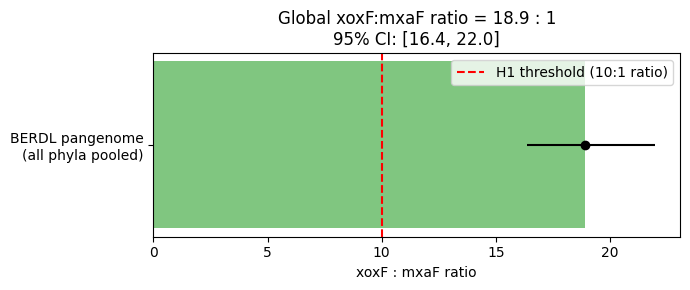

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(["BERDL pangenome\n(all phyla pooled)"], [ratio_point], color="#2ca02c", alpha=0.6)
ax.errorbar(
    [ratio_point], [0],
    xerr=[[ratio_point - ratio_lo], [ratio_hi - ratio_point]] if np.isfinite(ratio_hi) else [[ratio_point - ratio_lo], [ratio_point * 0.1]],
    fmt="o", color="black",
)
ax.axvline(10, ls="--", color="red", label="H1 threshold (10:1 ratio)")
ax.set_xlabel("xoxF : mxaF ratio")
ax.set_title(f"Global xoxF:mxaF ratio = {ratio_point:.1f} : 1\n95% CI: [{ratio_lo:.1f}, {ratio_hi:.1f}]")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "h1_global_ratio_with_CI.png", dpi=150)
plt.show()


## 8. Summary

**H1 verdict** (to be reported in REPORT.md):
- Global xoxF:mxaF ratio across BERDL pangenome
- One-sided binomial p-value against the 10:1 H1 threshold
- Per-phylum BH-corrected p-values: which phyla individually pass H1
- Limitations: phylogenetic non-independence (phyla aren't equal-weight statistical units; the analysis is *descriptive of the pangenome's annotation distribution* rather than a phylogenetically corrected evolutionary test).

NB04 will turn to H2 (environmental association).